# Task 3 — Topología de red y propagación SIR

En este notebook generamos tres redes sintéticas, medimos sus propiedades y simulamos un brote SIR sobre cada una para comparar cómo la estructura de la red afecta el contagio.

**Conceptos clave**

- **Grado $k_i$**: número de conexiones del nodo $i$. $\langle k \rangle$ es su promedio y $\langle k^2 \rangle$ el promedio de los grados al cuadrado (crece mucho cuando hay *hubs*, es decir, nodos muy conectados).
- **Clustering $C$**: qué tan conectados están entre sí los vecinos de un nodo (0 = nada, 1 = todos).
- **Distancia promedio $\langle d \rangle$**: número promedio de aristas en el camino más corto entre dos nodos.
- **Umbral epidémico**: el brote puede propagarse si $\beta/\gamma > \langle k \rangle / (\langle k^2 \rangle - \langle k \rangle)$.

Las funciones auxiliares están en `redes.py`.

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from redes import intervalo_confianza, metricas, rellenar, simular_sir

SEMILLA = 42
rng = np.random.default_rng(SEMILLA)

## Task 3.1 — Generación y caracterización de redes

Creamos las tres redes con NetworkX:

| Red | Modelo | Parámetros |
|---|---|---|
| Aleatoria | Erdős-Rényi | $N=500$, $p=0.02$ |
| Libre de escala | Barabási-Albert | $N=500$, $m=5$ |
| Mundo pequeño | Watts-Strogatz | $N=500$, $k=6$, $p=0.1$ |

In [2]:
N = 500
redes = {
    "Aleatoria (ER)": nx.erdos_renyi_graph(N, 0.02, seed=SEMILLA),
    "Libre de escala (BA)": nx.barabasi_albert_graph(N, 5, seed=SEMILLA),
    "Mundo pequeño (WS)": nx.watts_strogatz_graph(N, 6, 0.1, seed=SEMILLA),
}

### Tabla comparativa

Calculamos $\langle k \rangle$, $\langle k^2 \rangle$, $C$, $\langle d \rangle$ y el umbral crítico $(\beta/\gamma)_c$ de cada red.

In [3]:
tabla = pd.DataFrame({nombre: metricas(G) for nombre, G in redes.items()}).T
tabla.round(4)

,<k>,<k^2>,C,<d>,(β/γ)_c
Aleatoria (ER),9.748,104.216,0.0161,2.9674,0.1032
Libre de escala (BA),9.900,203.112,0.0790,2.7308,0.0512
Mundo pequeño (WS),6.000,36.488,0.4645,5.6972,0.1968


### Distribución de grado $P(k)$

$P(k)$ es la fracción de nodos con grado $k$. Para la red libre de escala usamos ejes log-log (logarítmicos en ambos ejes), donde una ley de potencias se ve como una línea recta.

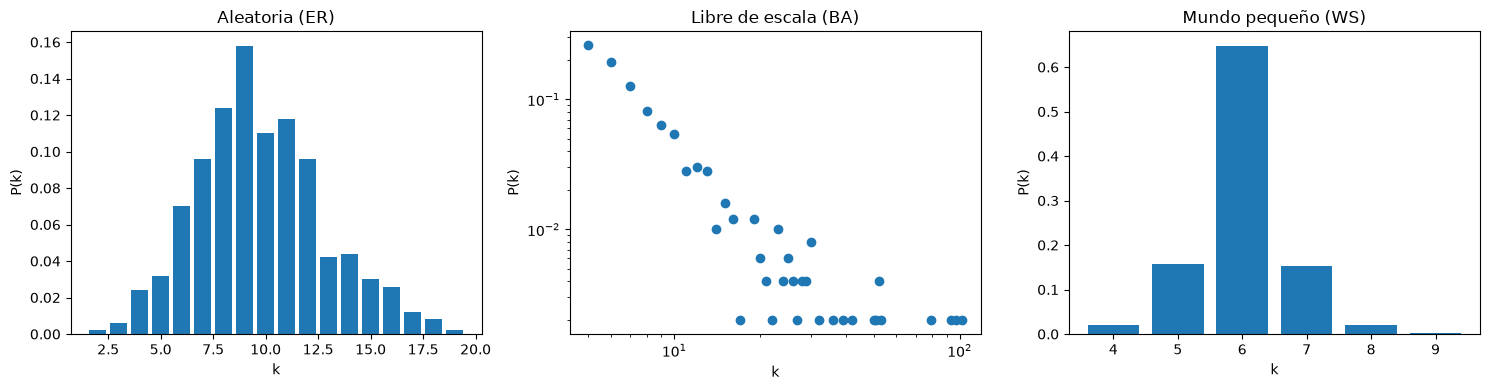

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nombre, G) in zip(axes, redes.items()):
    grados = np.array([d for _, d in G.degree()])
    k, conteo = np.unique(grados, return_counts=True)
    Pk = conteo / N
    if "BA" in nombre:
        ax.loglog(k, Pk, "o")
    else:
        ax.bar(k, Pk)
    ax.set_title(nombre)
    ax.set_xlabel("k")
    ax.set_ylabel("P(k)")

plt.tight_layout()
plt.show()

## Task 3.2 — Simulación SIR sobre las redes

Cada nodo está en uno de tres estados: **S** (susceptible), **I** (infectado) o **R** (recuperado). En cada paso de tiempo:

1. Cada infectado contagia a cada vecino susceptible con probabilidad $\beta = 0.04$.
2. Cada infectado se recupera con probabilidad $\gamma = 0.03$.

Iniciamos con 5 infectados al azar y repetimos la simulación 50 veces por red. El **tamaño final del brote** es la fracción de la población que llegó a infectarse.

In [5]:
BETA, GAMMA = 0.04, 0.03
N_INICIAL, REALIZACIONES = 5, 50

resultados = {}
for nombre, G in redes.items():
    trayectorias, tamanos = [], []
    for _ in range(REALIZACIONES):
        I_t, tamano = simular_sir(G, BETA, GAMMA, N_INICIAL, rng)
        trayectorias.append(I_t)
        tamanos.append(tamano)
    resultados[nombre] = {"I_t": rellenar(trayectorias), "tamanos": np.array(tamanos)}

### Tamaño final del brote: media e intervalo de confianza del 95%

El intervalo de confianza (IC) indica el rango donde esperamos que esté la media real con 95% de confianza. También reportamos la desviación estándar para medir la variabilidad entre realizaciones.

In [6]:
filas = {}
for nombre, r in resultados.items():
    media, inf, sup = intervalo_confianza(r["tamanos"])
    filas[nombre] = {
        "Media": media,
        "IC 95% inf": inf,
        "IC 95% sup": sup,
        "Desv. estándar": r["tamanos"].std(ddof=1),
        "β/γ": BETA / GAMMA,
        "(β/γ)_c": tabla.loc[nombre, "(β/γ)_c"],
    }
pd.DataFrame(filas).T.round(4)

,Media,IC 95% inf,IC 95% sup,Desv. estándar,β/γ,(β/γ)_c
Aleatoria (ER),0.9970,0.9963,0.9977,0.0025,1.3333,0.1032
Libre de escala (BA),0.9944,0.9935,0.9953,0.0031,1.3333,0.0512
Mundo pequeño (WS),0.9831,0.9788,0.9873,0.0149,1.3333,0.1968


### Trayectorias de $I(t)/N$

Cada línea delgada es una realización; la línea gruesa es la media de las 50.

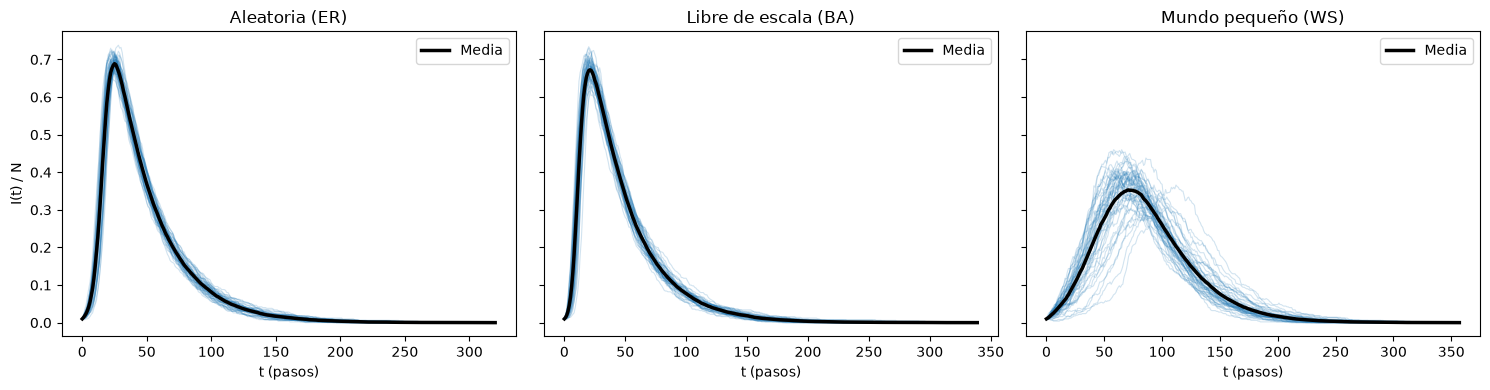

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (nombre, r) in zip(axes, resultados.items()):
    I_t = r["I_t"]
    ax.plot(I_t.T, color="tab:blue", alpha=0.2, linewidth=0.8)
    ax.plot(I_t.mean(axis=0), color="black", linewidth=2.5, label="Media")
    ax.set_title(nombre)
    ax.set_xlabel("t (pasos)")
    ax.legend()

axes[0].set_ylabel("I(t) / N")
plt.tight_layout()
plt.show()

### Comparación entre topologías

**¿En cuál red el brote alcanza mayor tamaño?**

En la red aleatoria (ER), con una media de **0.9970** (IC 95%: 0.9963–0.9977). Le sigue la libre de escala (BA) con **0.9944** y, al final, la de mundo pequeño (WS) con **0.9831**. En ER y BA el brote casi llega a toda la población.

**¿En cuál es más variable entre realizaciones?**

En la de mundo pequeño (WS): su desviación estándar (**0.0149**) es unas 5 veces mayor que la de ER (0.0025) y BA (0.0031), y su IC es el más ancho. En la figura también se ve, las trayectorias de WS se dispersan más en el pico (entre 0.30 y 0.46) y en el momento en que ocurre, mientras que en ER y BA casi se superponen.

**¿Son consistentes con el umbral epidémico del Task 3.1?**

Sí. En las tres redes $\beta/\gamma = 1.333$ supera por mucho el umbral crítico (ER: 0.1032, BA: 0.0512, WS: 0.1968), así que en todas se espera un brote grande, y eso ocurre (tamaño final > 0.98). Además, WS tiene el umbral más alto (la red más cercana a no propagar) y es donde el brote es menor y más variable, porque su bajo $\langle k \rangle = 6$ y su alto clustering ($C = 0.46$) hacen que el contagio avance más lento por grupos locales. Sin embargo, el umbral no ordena exactamente los tamaños, BA tiene el umbral más bajo, pero ER alcanza un tamaño apenas mayor. Esto se debe a que el umbral solo indica *si* el brote puede propagarse; cuando $\beta/\gamma$ está muy por encima del umbral en ambas redes, las dos quedan casi saturadas y la diferencia (0.0026) es muy pequeña.